<a href="https://colab.research.google.com/github/NorahMT/Individual-s_Annual_Income_Classification_Machine_Learning/blob/main/Individual's_Annual_Income_Classification_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title 1- Importing the packages
import numpy as np  # for numerical operations
import pandas as pd  # for data manipulation and analysis
import matplotlib.pyplot as plt  # for data visualization
from sklearn.model_selection import train_test_split  # for data splitting
from sklearn.preprocessing import MinMaxScaler, StandardScaler  # for feature scaling
from sklearn.svm import SVC  # for Support Vector Classifier
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report  # for evaluation
import seaborn as sns # for statistical graphics
from sklearn.tree import DecisionTreeClassifier #to build the decision tree model
from sklearn.tree import plot_tree #for visualizing decision tree models
from sklearn.neighbors import KNeighborsClassifier #estimation of the Knn model and outcome report

------------------------------------------------------

In [ ]:
# @title 2- Importing the selected dataset and visualizing the dataset contents
# Define column names
column_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

# Load the training dataset
train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
train_data = pd.read_csv(train_url, header=None, names=column_names, na_values=" ?", skipinitialspace=True)

# Load the testing dataset
test_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"
test_data = pd.read_csv(test_url,
                        header=None, # No header row in the file, as column names are not provided in the file
                        names=column_names, # Assign the custom column names to the DataFrame from the `column_names` list
                        na_values=" ?",  # "?" in the dataset are missing values
                        skipinitialspace=True,  # Ignore any extra spaces after delimiters (commas) when parsing the file
                        skiprows=1  # Skip the first row in the file (metadata)
                        )

# Check the results
print("The number of train data:")
print(train_data.shape[0])
print("\nThe number of test data:")
print(test_data.shape[0])
print("\n____________________________________________")

test_data.head()

The number of train data:
32561

The number of test data:
16281

____________________________________________


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K.


------------------------------------------------------

In [ ]:
# @title 3a- Train Data
# Count to check if there are null values in the column
train_data.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
train_data

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
# replace ? value to null value
train_data.replace('?', None, inplace=True)
test_data.replace('?', None, inplace=True)

# count to check if there are null values in the column
train_data.isna().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
# Display a summary of the DataFrame
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
# Count the occurrences of each class (<=50K, >50K) in the 'income' column
train_data.income.value_counts()

,count
income,
<=50K,24720
>50K,7841


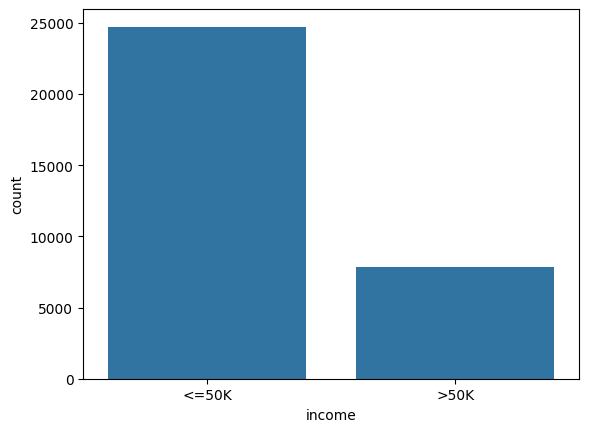

In [ ]:
# Visualize income distribution for training data
sns.countplot(x='income', data=train_data)
plt.show()

In [ ]:
# @title 3b- Test Data
test_data.isna().sum() # count the null values in the column

,0
age,0
workclass,963
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,966
relationship,0
race,0
sex,0


In [ ]:
test_data

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,None,103497,Some-college,10,Never-married,None,Own-child,White,Female,0,0,30,United-States,<=50K.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16276,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
16277,64,None,321403,HS-grad,9,Widowed,None,Other-relative,Black,Male,0,0,40,United-States,<=50K.
16278,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
16279,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [ ]:
test_data['income'] = test_data['income'].replace('<=50K.', '<=50K')
test_data['income'] = test_data['income'].replace('>50K.', '>50K')

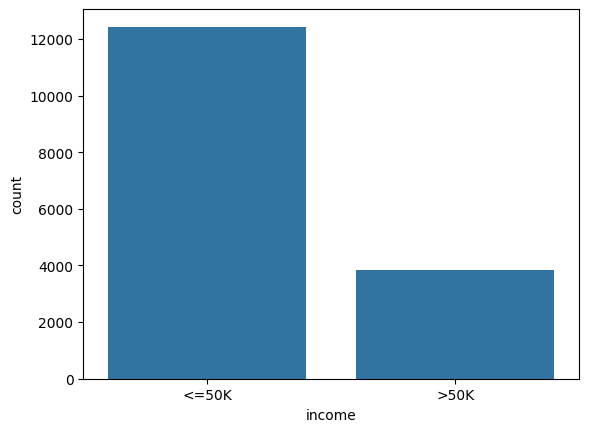

In [ ]:
# Visualize income distribution for test data
sns.countplot(x='income', data=test_data)
plt.show()

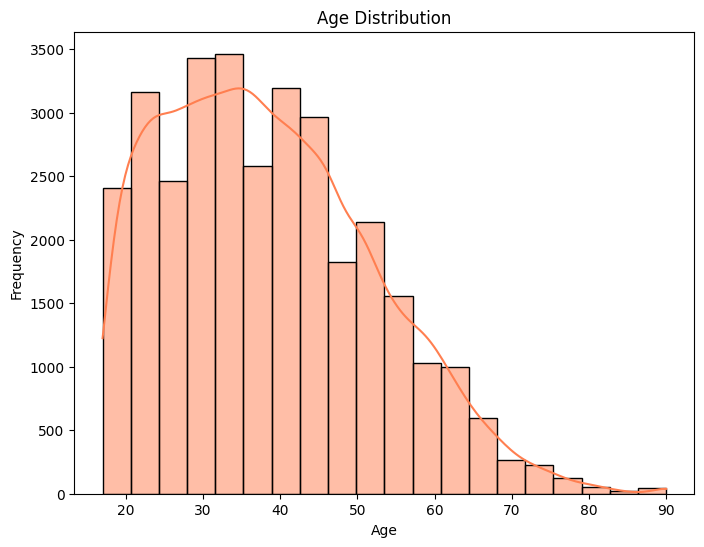

In [ ]:
# Visualize age distribution
plt.figure(figsize=(8, 6))
sns.histplot(train_data['age'], bins=20, kde=True, color='coral')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

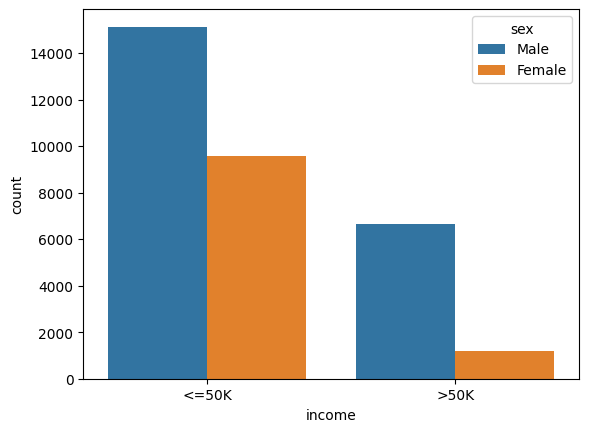

In [ ]:
sns.countplot(x='income', hue='sex', data=train_data)
plt.show()

------------------------------------------------------

In the following step we combine training and test data to perform preprocessing, which ensures consistency and prevents "data leakage" between the training and testing stages

In [ ]:
# @title 4- Data preprocessing
#Combine the Training and Test Data
combined_data = pd.concat([train_data, test_data], ignore_index=True)
combined_data.head(4)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K


In [ ]:
combined_data.shape[0]

48842

In [ ]:
combined_data.isna().sum() # count to check if there are null values in the column

,0
age,0
workclass,2799
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,2809
relationship,0
race,0
sex,0


the results show three class with null "missing" values, to fix this we fill the missing values with the **Most Frequent Value**

In [ ]:
# Fill missing values in 'workclass'
mode_value_workclass = combined_data['workclass'].mode()[0]
combined_data['workclass'] = combined_data['workclass'].fillna(mode_value_workclass)

# Fill missing values in 'occupation'
mode_value_occupation = combined_data['occupation'].mode()[0]
combined_data['occupation'] = combined_data['occupation'].fillna(mode_value_occupation)

# Fill missing values in 'native-country'
mode_value_native_country = combined_data['native_country'].mode()[0]
combined_data['native_country'] = combined_data['native_country'].fillna(mode_value_native_country)

In [ ]:
 combined_data.isna().sum() # check if there are still null values in the column

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
 combined_data

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
48838,64,Private,321403,HS-grad,9,Widowed,Prof-specialty,Other-relative,Black,Male,0,0,40,United-States,<=50K
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K


------------------------------------------------------

Encoding converts non-numeric categorical data (e.g., 'Male', 'Female') into a numerical format that the model can understand while preserving the information about the categories.
Here, **One-Hot Encoding** is used for nominal data to avoid introducing artificial ordering.

In [ ]:
#One Hot Encoding Categorical Variables
#get all categorical columns
categ_columns = combined_data.select_dtypes(['object']).columns

#convert all categorical columns to numeric
combined_data[categ_columns] = combined_data[categ_columns].apply(lambda x: pd.factorize(x)[0])

#print head of data after convert
combined_data

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,0,77516,0,13,0,0,0,0,0,2174,0,40,0,0
1,50,1,83311,0,13,1,1,1,0,0,0,0,13,0,0
2,38,2,215646,1,9,2,2,0,0,0,0,0,40,0,0
3,53,2,234721,2,7,1,2,1,1,0,0,0,40,0,0
4,28,2,338409,0,13,1,3,2,1,1,0,0,40,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,2,215419,0,13,2,3,0,0,1,0,0,36,0,0
48838,64,2,321403,1,9,6,3,5,1,0,0,0,40,0,0
48839,38,2,374983,0,13,1,3,1,0,0,0,0,50,0,0
48840,44,2,83891,0,13,2,0,3,2,0,5455,0,40,0,0


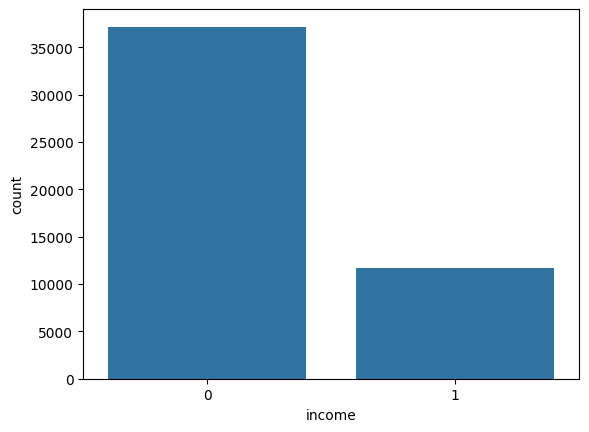

In [ ]:
# Visualize income distribution
sns.countplot(x='income', data=combined_data)
plt.show()

Apply Normalization since SVM relies on distance to define margins, and k-NN calculates distances to identify neighbors making them sensitive to feature scales.


In [ ]:
# Separate features and target
X_combined_data = combined_data.drop('income', axis=1)
y_combined_data = combined_data['income']

# Apply Min-Max Normalization to features
scaler = MinMaxScaler()
X_combined_data_normalized = scaler.fit_transform(X_combined_data)


# Convert back to DataFrame for better readability
combined_data= pd.DataFrame(X_combined_data_normalized, columns=X_combined_data.columns)

combined_data =combined_data.join(y_combined_data)

combined_data

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.301370,0.000000,0.044131,0.000000,0.800000,0.000000,0.000000,0.0,0.00,0.0,0.021740,0.0,0.397959,0.000,0
1,0.452055,0.142857,0.048052,0.000000,0.800000,0.166667,0.076923,0.2,0.00,0.0,0.000000,0.0,0.122449,0.000,0
2,0.287671,0.285714,0.137581,0.066667,0.533333,0.333333,0.153846,0.0,0.00,0.0,0.000000,0.0,0.397959,0.000,0
3,0.493151,0.285714,0.150486,0.133333,0.400000,0.166667,0.153846,0.2,0.25,0.0,0.000000,0.0,0.397959,0.000,0
4,0.150685,0.285714,0.220635,0.000000,0.800000,0.166667,0.230769,0.4,0.25,1.0,0.000000,0.0,0.397959,0.025,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0.301370,0.285714,0.137428,0.000000,0.800000,0.333333,0.230769,0.0,0.00,1.0,0.000000,0.0,0.357143,0.000,0
48838,0.643836,0.285714,0.209130,0.066667,0.533333,1.000000,0.230769,1.0,0.25,0.0,0.000000,0.0,0.397959,0.000,0
48839,0.287671,0.285714,0.245379,0.000000,0.800000,0.166667,0.230769,0.2,0.00,0.0,0.000000,0.0,0.500000,0.000,0
48840,0.369863,0.285714,0.048444,0.000000,0.800000,0.333333,0.000000,0.6,0.50,0.0,0.054551,0.0,0.397959,0.000,0


Separate the Combined Data Back Into Train and Test

In [ ]:
# Get the original number of rows for the training data
train_size = len(train_data)

# Separate the combined data back into train and test sets
train_data_separated = combined_data.iloc[:train_size]
test_data_separated = combined_data.iloc[train_size:]

# Check the results
print("Train Data Separated:")
print(train_data_separated.shape[0])
print("\nTest Data Separated:")
print(test_data_separated.shape[0])

Train Data Separated:
32561

Test Data Separated:
16281


In [ ]:
# Separate features and target
X_train = train_data_separated.drop('income', axis=1)
y_train = train_data_separated['income']
X_test = test_data_separated.drop('income', axis=1)
y_test = test_data_separated['income']

test_data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,None,103497,Some-college,10,Never-married,None,Own-child,White,Female,0,0,30,United-States,<=50K


------------------------------------------------------

In [ ]:
# @title 5- Setting Up the SVM Model

# Initialize the SVM classifier with default parameters
SVM_classifier = SVC()

# initialize SVM classifier
SVM_classifier = SVC(kernel='rbf')

**Training the SVM Model**

In [ ]:
# X_train represent the training features, and y_train represent the training labels.
# The initialized SVM classifier is 'SVM_classifier'

# Train the SVM classifier using the training data
SVM_classifier.fit(X_train, y_train)

SVC()

**Testing and Evaluating the SVM Model**

Accuracy: 0.8483508384005897


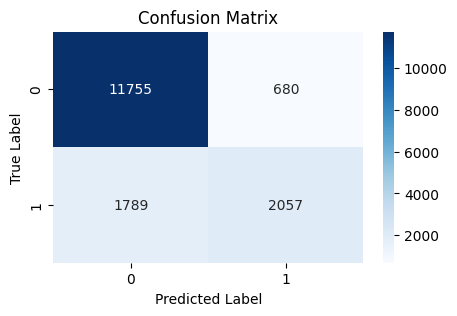

In [ ]:
# Make predictions using the test data
y_pred_svm = SVM_classifier.predict(X_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred_svm)
print("Accuracy:", accuracy)

# Make a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_svm)

# Plot confusion matrix
plt.figure(figsize=(5,3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
# Evaluating the model
print(confusion_matrix(y_test, y_pred_svm))  # confusion matrix
print("____________________________________________\n")
print(classification_report(y_test, y_pred_svm))  # classification report

[[11755   680]
 [ 1789  2057]]
____________________________________________

              precision    recall  f1-score   support

           0       0.87      0.95      0.90     12435
           1       0.75      0.53      0.62      3846

    accuracy                           0.85     16281
   macro avg       0.81      0.74      0.76     16281
weighted avg       0.84      0.85      0.84     16281



Based on the provided classification report:
the model shows very high precision and recall for class 0, indicating the instances of that class are reliably set. The recall for class 1 is appreciably worse, hinting toward undetected instances. Although the accuracy is very good at 84%, further investigation of the balance between precision and recall or possible strategies to improve the performance.


------------------------------------------------------

In [ ]:
# @title 6- Setting Up the Decision Tree Model
# perform training with entropy
# Decision tree with entropy
clf = DecisionTreeClassifier(criterion = "entropy", random_state = 42,max_depth = 4, min_samples_leaf =5)
# Fit the model
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=5,
                       random_state=42)

**Training the Decision Tree Model**

In [ ]:
# Predictions on the test set
y_pred = clf.predict(X_test)

# Confusion matrix and performance metrics
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy)
print("Classification Report:\n", report)

Confusion Matrix:
 [[11804   631]
 [ 1896  1950]]
Accuracy: 0.8447884036607088
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90     12435
           1       0.76      0.51      0.61      3846

    accuracy                           0.84     16281
   macro avg       0.81      0.73      0.76     16281
weighted avg       0.84      0.84      0.83     16281



**Testing and Evaluating the Decision Tree Model**

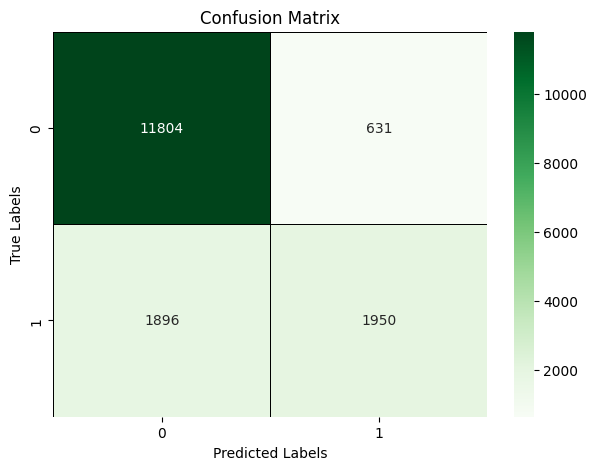

In [ ]:
# Create a heatmap for the confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', linewidths=0.5, linecolor='black')

# Add labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')

# Display the plot
plt.show()

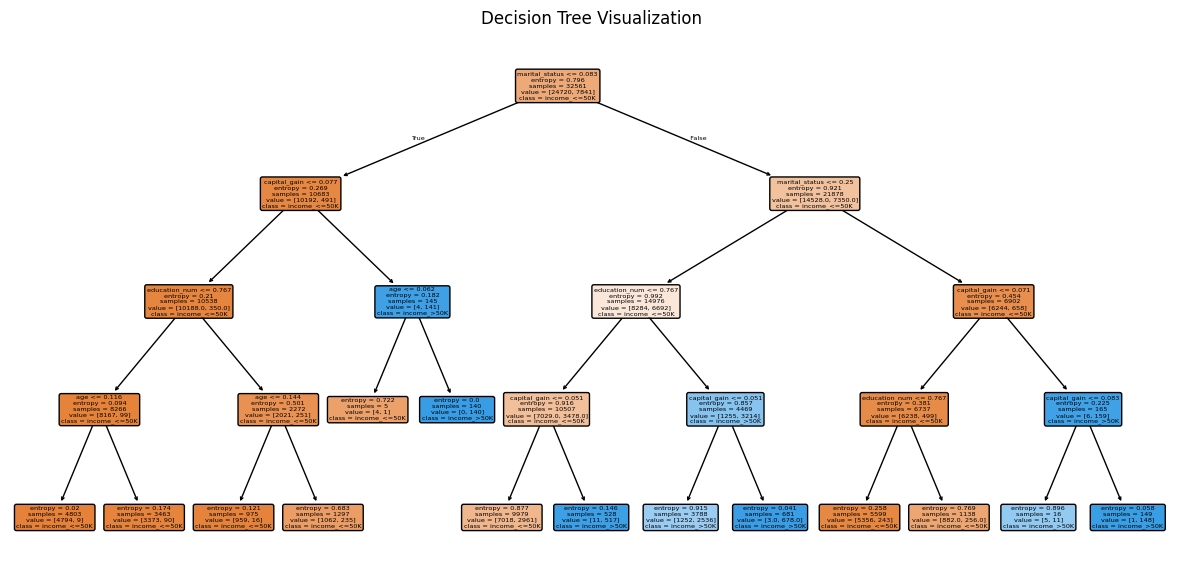

In [ ]:
# Plot the decision tree
plt.figure(figsize=(15, 7))  # Adjust the size as needed
plot_tree(clf, feature_names=X_train.columns, class_names=['income_<=50K', 'income_>50K'], filled=True, rounded=True)

# Add title
plt.title('Decision Tree Visualization')

# Display the plot
plt.show()

Based on the provided classification report: the model shows the overall accuracy is strong, with  high accuracy for class 0 but struggles with classifying 1 (many False Negatives)  

------------------------------------------------------

Confusion Matrix:
 [[11298  1137]
 [ 1657  2189]]
Accuracy: 0.8283889195995332
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.91      0.89     12435
           1       0.66      0.57      0.61      3846

    accuracy                           0.83     16281
   macro avg       0.77      0.74      0.75     16281
weighted avg       0.82      0.83      0.82     16281

Accuracy: 0.8283889195995332


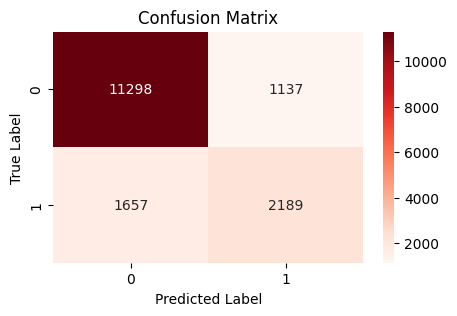

In [ ]:
# @title 7- Setting Up the KNN Model
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
# Predictions on the test set
y_pred_knn = knn.predict(X_test)

# Confusion matrix and performance metrics
cm = confusion_matrix(y_test, y_pred_knn)
accuracy = accuracy_score(y_test, y_pred_knn)
report = classification_report(y_test, y_pred_knn)

print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy)
print("Classification Report:\n", report)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_knn)
print("Accuracy:", accuracy)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_knn)

# Plot confusion matrix
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Based on the provided classification report: the model shows that the overall accuracy is strong, but the imbalance in performance across classes suggests room for improvement, especially for the minority class (Class 1).

In [ ]:
print("Number of features:", X_train.shape[1])
print("Feature names:\n", list(X_train.columns))


Number of features: 14
Feature names:
 ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country']


In [ ]:
print(train_data.describe())


                age        fnlwgt  education_num  capital_gain  capital_loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours_per_week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


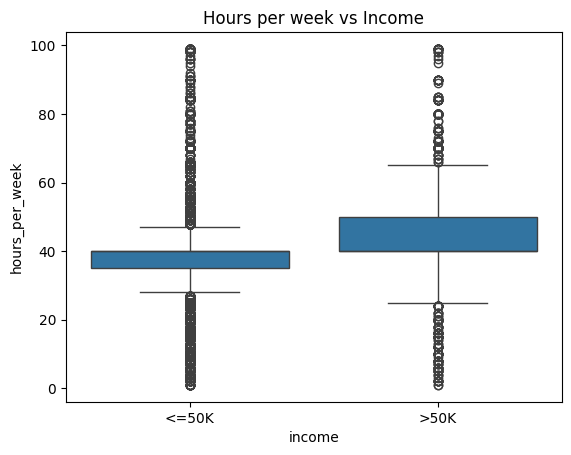

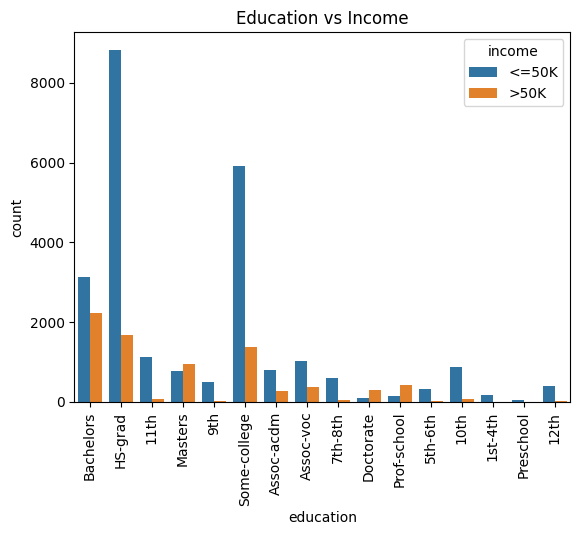

In [ ]:
sns.boxplot(x='income', y='hours_per_week', data=train_data)
plt.title("Hours per week vs Income")
plt.show()

sns.countplot(x='education', hue='income', data=train_data)
plt.xticks(rotation=90)
plt.title("Education vs Income")
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(y_true, y_pred, model_name):
    print(f"{model_name}:\n")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))
    print("\n")
evaluate_model(y_test, y_pred_svm, "SVM")
evaluate_model(y_test, y_pred, "Decision Tree")
evaluate_model(y_test, y_pred_knn, "KNN")


SVM:

Accuracy: 0.8483508384005897
Confusion Matrix:
 [[11755   680]
 [ 1789  2057]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.90     12435
           1       0.75      0.53      0.62      3846

    accuracy                           0.85     16281
   macro avg       0.81      0.74      0.76     16281
weighted avg       0.84      0.85      0.84     16281



Decision Tree:

Accuracy: 0.8447884036607088
Confusion Matrix:
 [[11804   631]
 [ 1896  1950]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90     12435
           1       0.76      0.51      0.61      3846

    accuracy                           0.84     16281
   macro avg       0.81      0.73      0.76     16281
weighted avg       0.84      0.84      0.83     16281



KNN:

Accuracy: 0.8283889195995332
Confusion Matrix:
 [[11298  1137]
 [ 1657  2189]]
Classification Report:
      

In [ ]:
results = []

results.append(["SVM", accuracy_score(y_test, y_pred_svm)])
results.append(["Decision Tree", accuracy_score(y_test, y_pred)])
results.append(["KNN", accuracy_score(y_test, y_pred_knn)])

import pandas as pd
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print(results_df)


           Model  Accuracy
0            SVM  0.848351
1  Decision Tree  0.844788
2            KNN  0.828389


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# دالة التقييم ترجع النتائج كقاموس بدل الطباعة فقط
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True)  # ناخذ التقرير كـ dict

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-Score": report["weighted avg"]["f1-score"],
        "Confusion_Matrix": cm.tolist()  # نخزنها كـ list عشان تدخل CSV
    }

# نجمع النتائج لكل مودل
results = []
results.append(evaluate_model(y_test, y_pred_svm, "SVM"))
results.append(evaluate_model(y_test, y_pred, "Decision Tree"))
results.append(evaluate_model(y_test, y_pred_knn, "KNN"))

# تحويل إلى DataFrame
results_df = pd.DataFrame(results)

# تصدير CSV
results_df.to_csv("model_results.csv", index=False)

print("✅ تم حفظ النتائج في model_results.csv")
print(results_df)


✅ تم حفظ النتائج في model_results.csv
           Model  Accuracy  Precision    Recall  F1-Score  \
0            SVM  0.848351   0.840425  0.848351  0.838814   
1  Decision Tree  0.844788   0.836546  0.844788  0.833270   
2            KNN  0.828389   0.821556  0.828389  0.823925   

                Confusion_Matrix  
0   [[11755, 680], [1789, 2057]]  
1   [[11804, 631], [1896, 1950]]  
2  [[11298, 1137], [1657, 2189]]  


In [ ]:
import pandas as pd

# حول income إلى رقم
train_data["income_num"] = train_data["income"].apply(lambda x: 1 if x == ">50K" else 0)

# احسب الارتباط
corr = train_data.corr(numeric_only=True)["income_num"].sort_values(ascending=False)
print(corr)


income_num        1.000000
education_num     0.335154
age               0.234037
hours_per_week    0.229689
capital_gain      0.223329
capital_loss      0.150526
fnlwgt           -0.009463
Name: income_num, dtype: float64
